# Kernel PCA, ICA, and NMF

### Three ways to leave PCA behind, each for a different reason

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How kernel PCA runs PCA in a space it never builds, how ICA recovers mixed-together sources and how to score that recovery when the answer has no ordering, why ICA on Gaussian sources returns a plausible-looking number that means nothing, how NMF produces parts instead of ghosts, and what non-negativity costs in reconstruction error |
| **You should already know** | [PCA](../01-principal-component-analysis/), and ideally the [kernel trick from support vector machines](../../03-classification/05-support-vector-machines/) |
| **Datasets** | `make_circles` for kernel PCA, synthetic signals with known sources for ICA, Fashion-MNIST for NMF |
| **Runtime** | Two to four minutes on a laptop CPU |
| **Next** | [06-03 t-SNE](../03-t-sne/) |

---

## 1. The idea

[PCA](../01-principal-component-analysis/) does one thing: it finds the
orthogonal directions of greatest variance. Three complaints follow from that
sentence, and this notebook is one method per complaint.

| complaint | method | what it optimises instead |
|---|---|---|
| PCA is linear, so curved structure is flattened and lost | **Kernel PCA** | variance, but computed in a non-linear feature space it never actually constructs |
| Uncorrelated is a much weaker property than independent | **ICA** | components as statistically independent, and therefore as far from Gaussian, as possible |
| Components with negative weights subtract, so they are not parts of anything | **NMF** | a reconstruction where everything, weights and codes alike, is non-negative |

The three are not variants of each other. They answer different questions and
they fail in different ways, so each gets its own dataset, chosen so that the
right answer is known and the result can be scored rather than admired.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

from sklearn.datasets import make_circles

X_circles, y_circles = make_circles(n_samples=600, factor=0.32, noise=0.06,
                                    random_state=SEED)
print(f"{len(X_circles)} points on two concentric circles, "
      f"{X_circles.shape[1]} features, {len(set(y_circles))} classes")
print("no straight line separates them, and PCA can only ever draw straight lines")

600 points on two concentric circles, 2 features, 2 classes
no straight line separates them, and PCA can only ever draw straight lines


## 2. The maths

### Kernel PCA

Suppose you map every point through some function $\phi$ into a much bigger
space, then run PCA there. In that space a curved boundary can become flat. The
obstacle is that the useful $\phi$ maps into a space too large to write down, and
sometimes an infinite one.

The escape is that PCA in feature space only ever needs **inner products**
$\phi(x_i)^\top \phi(x_j)$, never the vectors themselves. A **kernel** is a
function that returns those inner products directly:

$$k(x_i, x_j) = \phi(x_i)^\top \phi(x_j)$$

For the radial basis function kernel, $k(x_i,x_j) = \exp(-\gamma \|x_i-x_j\|^2)$,
the implied $\phi$ maps into infinitely many dimensions and you never touch it.

One detail that is easy to skip and breaks everything: PCA requires **centred**
data, and you cannot subtract a mean you cannot compute. Centring has to happen
inside the kernel matrix instead:

$$\tilde{K} = K - \mathbf{1}_n K - K \mathbf{1}_n + \mathbf{1}_n K \mathbf{1}_n$$

where $\mathbf{1}_n$ is the $n \times n$ matrix with every entry $1/n$. Then the
components are the eigenvectors of $\tilde{K}$, and the projection of the
training points is the eigenvectors scaled by the square roots of their
eigenvalues.

The price is written into that formula. $K$ is $n \times n$, so kernel PCA costs
memory and time quadratic in the number of rows, and the eigendecomposition is
cubic. PCA on $d$ columns costs $d \times d$ and does not care how many rows you
have.

### ICA

Now a different problem. Several signals were mixed together and you want them
back. Written as matrices, the observation is $X = S A^\top$: unknown sources
$S$, unknown mixing $A$, and only $X$ in hand.

PCA cannot do this. PCA produces components that are **uncorrelated**, which for
non-Gaussian variables is much weaker than **independent**, and it produces them
in a specific rotation chosen by variance. Sources have no reason to be arranged
along the directions of greatest variance.

ICA looks for an unmixing $W$ such that the rows of $XW$ are as independent as
possible. The route to that is odd and worth stating plainly. By the central
limit theorem, a sum of independent variables is more Gaussian than its parts. A
mixture is such a sum. So **the direction that is least Gaussian is the one that
has been mixed least**, and maximising non-Gaussianity recovers the sources.
FastICA measures non-Gaussianity through an approximation of negentropy.

Two things follow immediately and both matter for scoring.

**Order is arbitrary.** Nothing distinguishes the first recovered source from the
second. **Scale and sign are arbitrary too**, because multiplying a source by a
constant and dividing the corresponding mixing column by the same constant leaves
$X$ unchanged. Any honest evaluation has to search over permutations and ignore
sign, which section 4 does with an assignment solver.

And one prediction, which section 5 tests: **if the sources are Gaussian, the
solution is not identified.** For Gaussian variables uncorrelated is independent,
so every rotation of the whitened data is equally good and there is nothing to
choose between them. Note what that does and does not say. It says the objective
cannot prefer the true rotation over any other. It does not say the output will
look wrong, and section 5 measures what it looks like instead of assuming.

### NMF

Given a non-negative $X$, find non-negative $W$ and $H$ with

$$X \approx W H, \qquad W \ge 0,\ H \ge 0$$

minimising $\|X - WH\|_F^2$. The rows of $H$ are components, the rows of $W$ are
each row's non-negative recipe over them.

The whole content is the two inequality signs. In PCA a component can be
subtracted, so components are free to be global patterns that cancel each other
out. With non-negativity nothing can cancel, so the only way to build a picture
is out of pieces that are each present or absent. That is why NMF on images
produces parts and PCA produces ghosts.

The standard solver is Lee and Seung's **multiplicative update**, which keeps
non-negativity for free by only ever multiplying by non-negative ratios:

$$H \leftarrow H \odot \frac{W^\top X}{W^\top W H}, \qquad
  W \leftarrow W \odot \frac{X H^\top}{W H H^\top}$$

The objective is not jointly convex in $W$ and $H$, so the answer depends on the
initialisation. Fix the seed and say so.

## 3. From scratch

Kernel PCA first, because it is short and the centring step is the part people
get wrong.

In [2]:
class KernelPCAScratch:
    """Kernel PCA with an RBF kernel, through the centred Gram matrix."""

    def __init__(self, n_components=2, gamma=1.0):
        self.n_components = n_components
        self.gamma = gamma

    def _kernel(self, A, B):
        # ||a - b||^2 expanded, which avoids building an (n, m, d) difference array
        squared = (np.sum(A ** 2, axis=1)[:, None]
                   + np.sum(B ** 2, axis=1)[None, :]
                   - 2.0 * A @ B.T)
        return np.exp(-self.gamma * np.maximum(squared, 0.0))

    def fit_transform(self, X):
        X = np.asarray(X, dtype=float)
        n = len(X)
        K = self._kernel(X, X)

        # Centring in feature space. Skipping this is the classic bug: the first
        # component then points at the mean of phi(X) and carries no information.
        ones = np.full((n, n), 1.0 / n)
        K_centred = K - ones @ K - K @ ones + ones @ K @ ones

        eigenvalues, eigenvectors = np.linalg.eigh(K_centred)
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[order][:self.n_components]
        eigenvectors = eigenvectors[:, order][:, :self.n_components]

        self.eigenvalues_ = eigenvalues
        # Projection onto a unit-norm feature-space axis is alpha * sqrt(lambda).
        return eigenvectors * np.sqrt(np.maximum(eigenvalues, 0.0))


GAMMA = 4.0
mine = KernelPCAScratch(n_components=2, gamma=GAMMA).fit_transform(X_circles)

from sklearn.decomposition import KernelPCA

theirs = KernelPCA(n_components=2, kernel="rbf", gamma=GAMMA).fit_transform(X_circles)

# Signs of eigenvectors are arbitrary, so compare on absolute correlation.
agreement = [abs(np.corrcoef(mine[:, i], theirs[:, i])[0, 1]) for i in range(2)]
print(f"gamma = {GAMMA}")
print(f"absolute correlation with sklearn, component 1: {agreement[0]:.6f}")
print(f"absolute correlation with sklearn, component 2: {agreement[1]:.6f}")
print("(the sign of an eigenvector is arbitrary, so 1.0 in absolute value is exact agreement)")

gamma = 4.0
absolute correlation with sklearn, component 1: 1.000000
absolute correlation with sklearn, component 2: 1.000000
(the sign of an eigenvector is arbitrary, so 1.0 in absolute value is exact agreement)


### NMF's multiplicative update, written out

Small enough to read in one go, and it makes clear that non-negativity is not
enforced by a constraint solver but by the shape of the update.

In [3]:
class NMFScratch:
    """Lee and Seung multiplicative updates for the Frobenius objective."""

    def __init__(self, n_components=16, n_iter=300, random_state=0, eps=1e-10):
        self.n_components = n_components
        self.n_iter = n_iter
        self.random_state = random_state
        self.eps = eps

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        rng = np.random.default_rng(self.random_state)
        n, d = X.shape

        # Random non-negative start. Everything below only ever multiplies by a
        # non-negative ratio, so W and H can never leave the non-negative orthant.
        self.W_ = rng.uniform(0.1, 1.0, size=(n, self.n_components))
        self.H_ = rng.uniform(0.1, 1.0, size=(self.n_components, d))
        self.errors_ = []

        for _ in range(self.n_iter):
            self.H_ *= (self.W_.T @ X) / (self.W_.T @ self.W_ @ self.H_ + self.eps)
            self.W_ *= (X @ self.H_.T) / (self.W_ @ self.H_ @ self.H_.T + self.eps)
            self.errors_.append(float(np.linalg.norm(X - self.W_ @ self.H_)))
        return self


# A small slice of Fashion-MNIST, purely to check the update rule works.
# `.data` is the raw uint8 array behind the dataset, so dividing by 255 gives
# exactly what the ToTensor transform would have returned, without paying for a
# per-image conversion.
train_set = datasets.fashion_mnist(train=True)

SCRATCH_K = 16
rng = np.random.default_rng(SEED)
pick = rng.choice(len(train_set.data), 800, replace=False)
small = train_set.data.numpy()[pick].reshape(len(pick), -1).astype(np.float64) / 255.0

scratch_nmf = NMFScratch(n_components=SCRATCH_K, n_iter=300, random_state=SEED).fit(small)

from sklearn.decomposition import NMF

sk_nmf = NMF(n_components=SCRATCH_K, init="nndsvda", max_iter=600, tol=1e-5,
             random_state=SEED).fit(small)

print(f"{small.shape[0]} images, {small.shape[1]} pixels, {SCRATCH_K} components")
print(f"ours    : ||X - WH||_F = {scratch_nmf.errors_[-1]:.3f} "
      f"after {scratch_nmf.n_iter} multiplicative updates")
print(f"sklearn : ||X - WH||_F = {sk_nmf.reconstruction_err_:.3f}")
print(f"smallest entry in our W: {scratch_nmf.W_.min():.3e}   "
      f"in our H: {scratch_nmf.H_.min():.3e}")
print("(non-negativity was never enforced, only never violated)")

800 images, 784 pixels, 16 components
ours    : ||X - WH||_F = 117.903 after 300 multiplicative updates
sklearn : ||X - WH||_F = 116.246
smallest entry in our W: 5.855e-206   in our H: 0.000e+00
(non-negativity was never enforced, only never violated)


C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 600 reached. Increase it to improve convergence.
  warnings.warn(


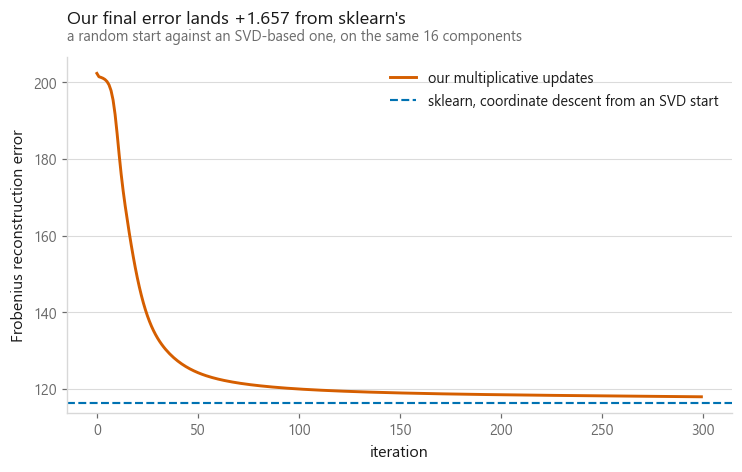

In [4]:
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.plot(scratch_nmf.errors_, color=style.HIGHLIGHT, ls="-", label="our multiplicative updates")
ax.axhline(sk_nmf.reconstruction_err_, color=style.PALETTE[0], ls="--", lw=1.4,
           label="sklearn, coordinate descent from an SVD start")
ax.set_xlabel("iteration")
ax.set_ylabel("Frobenius reconstruction error")
ax.legend(loc="upper right")
gap = scratch_nmf.errors_[-1] - sk_nmf.reconstruction_err_
style.title(ax, f"Our final error lands {gap:+.3f} from sklearn's",
            f"a random start against an SVD-based one, on the same {SCRATCH_K} components")
style.save(fig, FIG / "fig-01-nmf-convergence.png")

The dashed line is what a better initialisation buys. Both are running the same
objective; sklearn starts from a truncated SVD instead of random numbers, and on
a non-convex objective the starting point is part of the answer.

## 4. In practice

### Kernel PCA on data no line can cut

Two concentric circles. A linear classifier on the raw coordinates has no chance,
and neither does one on PCA components, because PCA in two dimensions is a
rotation and a rotation cannot make a circle linearly separable.

logistic regression, 5-fold cross-validated accuracy
  raw coordinates      : 0.4833
  PCA, 2 components    : 0.4800
  kernel PCA, gamma 4 : 1.0000

PCA and raw match because PCA on 2 columns into 2 components is a rotation


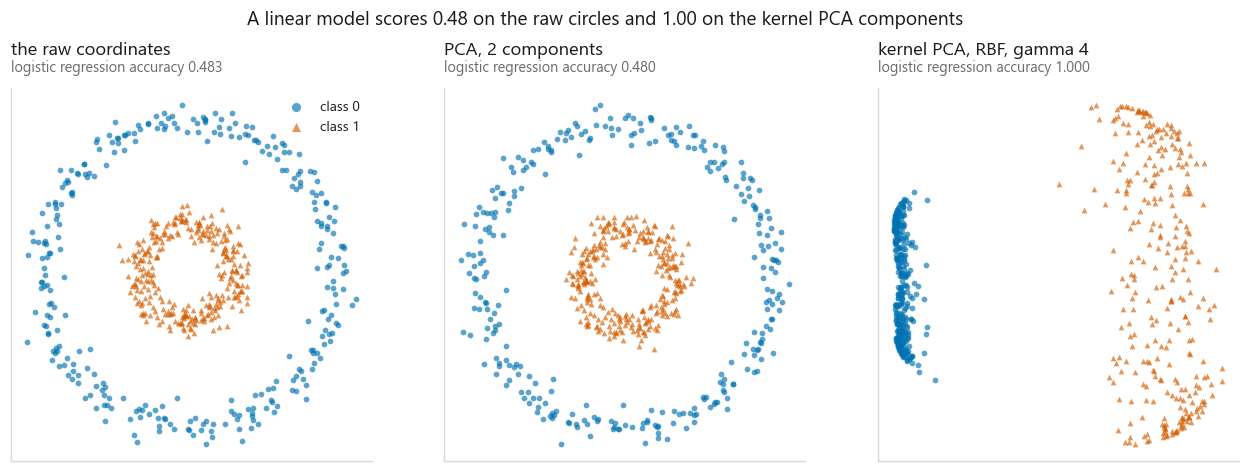

In [5]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

pca_points = PCA(n_components=2, random_state=SEED).fit_transform(X_circles)
kpca_points = KernelPCA(n_components=2, kernel="rbf", gamma=GAMMA).fit_transform(X_circles)

CV = 5
LINEAR = LogisticRegression(max_iter=2000)

raw_score = cross_val_score(LINEAR, X_circles, y_circles, cv=CV).mean()
pca_score = cross_val_score(make_pipeline(PCA(n_components=2, random_state=SEED), LINEAR),
                            X_circles, y_circles, cv=CV).mean()
kpca_score = cross_val_score(make_pipeline(KernelPCA(n_components=2, kernel="rbf",
                                                     gamma=GAMMA), LINEAR),
                             X_circles, y_circles, cv=CV).mean()

fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.4))
panels = [(X_circles, "the raw coordinates", raw_score),
          (pca_points, "PCA, 2 components", pca_score),
          (kpca_points, f"kernel PCA, RBF, gamma {GAMMA:g}", kpca_score)]

for ax, (points, name, score) in zip(axes, panels):
    for cls, marker in zip([0, 1], ["o", "^"]):
        sel = y_circles == cls
        ax.scatter(points[sel, 0], points[sel, 1], s=14, alpha=0.65, marker=marker,
                   c=style.PALETTE[cls * 3], linewidths=0, label=f"class {cls}")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    style.title(ax, name, f"logistic regression accuracy {score:.3f}")
axes[0].legend(loc="upper right", fontsize=9, markerscale=1.6)

fig.suptitle(f"A linear model scores {raw_score:.2f} on the raw circles and "
             f"{kpca_score:.2f} on the kernel PCA components",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-kernel-pca.png")

print(f"logistic regression, {CV}-fold cross-validated accuracy")
print(f"  raw coordinates      : {raw_score:.4f}")
print(f"  PCA, 2 components    : {pca_score:.4f}")
print(f"  kernel PCA, gamma {GAMMA:g} : {kpca_score:.4f}")
print("\nPCA and raw match because PCA on 2 columns into 2 components is a rotation")

### The dial that decides everything

`gamma` sets how quickly the kernel decides two points are unrelated. Too small
and the kernel is nearly linear, which puts you back where you started. Too large
and every point is its own island, which memorises rather than generalises. It
has to be tuned, and it is not optional.

 gamma  accuracy
  0.05    0.4817
  0.10    0.4767
  0.50    0.4867
  1.00    0.4883
  2.00    1.0000
  4.00    1.0000
 10.00    0.8183
 30.00    0.7050
100.00    0.6850


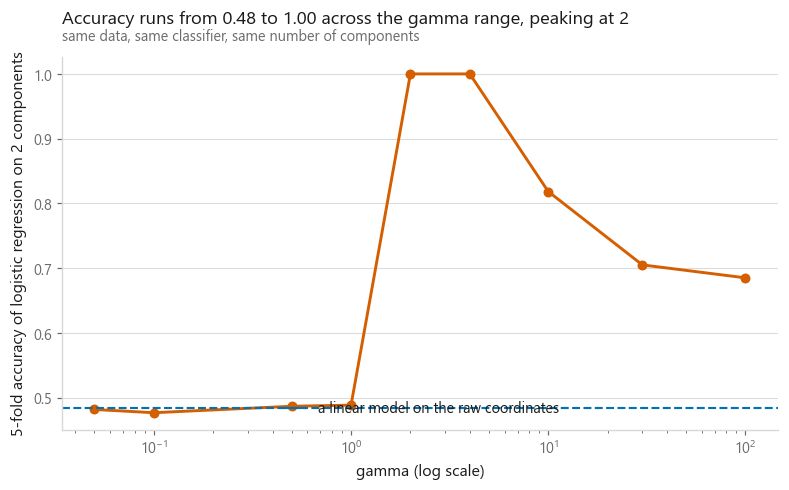

In [6]:
gammas = [0.05, 0.1, 0.5, 1.0, 2.0, 4.0, 10.0, 30.0, 100.0]
gamma_scores = []
for g in gammas:
    pipeline = make_pipeline(KernelPCA(n_components=2, kernel="rbf", gamma=g), LINEAR)
    gamma_scores.append(cross_val_score(pipeline, X_circles, y_circles, cv=CV).mean())

best_index = int(np.argmax(gamma_scores))
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.plot(gammas, gamma_scores, marker=style.MARKERS[0], ls="-", color=style.HIGHLIGHT)
ax.axhline(raw_score, color=style.PALETTE[0], ls="--", lw=1.4,
           label="a linear model on the raw coordinates")
ax.set_xscale("log")
ax.set_xlabel("gamma (log scale)")
ax.set_ylabel(f"{CV}-fold accuracy of logistic regression on 2 components")
ax.legend(loc="lower center")
style.title(ax,
            f"Accuracy runs from {min(gamma_scores):.2f} to {max(gamma_scores):.2f} "
            f"across the gamma range, peaking at {gammas[best_index]:g}",
            "same data, same classifier, same number of components")
style.save(fig, FIG / "fig-03-kpca-gamma.png")

print(pd.DataFrame({"gamma": gammas, "accuracy": np.round(gamma_scores, 4)}).to_string(index=False))

Both ends of that curve are worth naming. At small gamma the RBF kernel is nearly
linear and kernel PCA quietly becomes PCA. At large gamma every point is far from
every other, the kernel matrix approaches the identity, and the components stop
describing anything shared.

This is the real cost of kernel PCA, and it is larger than the compute. PCA has
no dial. Kernel PCA has a dial that moves the answer between the two panels
above, and it is unsupervised, so there is no held-out score inside the method
telling you where to put it. Here a downstream classifier provided one. Without a
downstream task you are choosing gamma by eye.

### ICA: getting the sources back, and scoring it honestly

Three signals, mixed by a random matrix. Because the sources were generated here,
the recovery can be measured rather than admired.

In [7]:
from scipy import signal as sp_signal
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import FastICA

N_SAMPLES = 2000
t = np.linspace(0, 8, N_SAMPLES)
sources = np.c_[np.sin(2 * t),                            # smooth
                np.sign(np.sin(3 * t)),                   # square, strongly non-Gaussian
                sp_signal.sawtooth(2 * np.pi * t)]        # ramp
source_rng = np.random.default_rng(SEED)
sources += 0.03 * source_rng.normal(size=sources.shape)
sources /= sources.std(axis=0)

mixing = source_rng.uniform(0.5, 2.0, size=(3, 3))
observed = sources @ mixing.T


def best_match(true, estimated):
    """Match estimated components to true sources, ignoring order and sign.

    ICA fixes neither, so a naive column-by-column correlation would understate
    a perfect recovery. The Hungarian algorithm finds the permutation that
    maximises the total absolute correlation.
    """
    k = true.shape[1]
    correlation = np.corrcoef(true.T, estimated.T)[:k, k:]
    rows, cols = linear_sum_assignment(-np.abs(correlation))
    return cols, correlation[rows, cols]


ica = FastICA(n_components=3, whiten="unit-variance", random_state=SEED, max_iter=2000)
recovered = ica.fit_transform(observed)
pca_recovered = PCA(n_components=3, random_state=SEED).fit_transform(observed)

ica_order, ica_corr = best_match(sources, recovered)
pca_order, pca_corr = best_match(sources, pca_recovered)

print("ICA, after solving for the best permutation")
for i, (j, c) in enumerate(zip(ica_order, ica_corr)):
    print(f"  true source {i} matched recovered component {j}, correlation {c:+.4f}")
print(f"  mean absolute correlation: {np.abs(ica_corr).mean():.4f}")
print("\nPCA on the same mixtures, same scoring")
for i, (j, c) in enumerate(zip(pca_order, pca_corr)):
    print(f"  true source {i} matched component {j}, correlation {c:+.4f}")
print(f"  mean absolute correlation: {np.abs(pca_corr).mean():.4f}")

ICA, after solving for the best permutation
  true source 0 matched recovered component 2, correlation +0.9968
  true source 1 matched recovered component 1, correlation +0.9995
  true source 2 matched recovered component 0, correlation +0.9970
  mean absolute correlation: 0.9977

PCA on the same mixtures, same scoring
  true source 0 matched component 2, correlation -0.7194
  true source 1 matched component 1, correlation +0.7920
  true source 2 matched component 0, correlation +0.5701
  mean absolute correlation: 0.6938


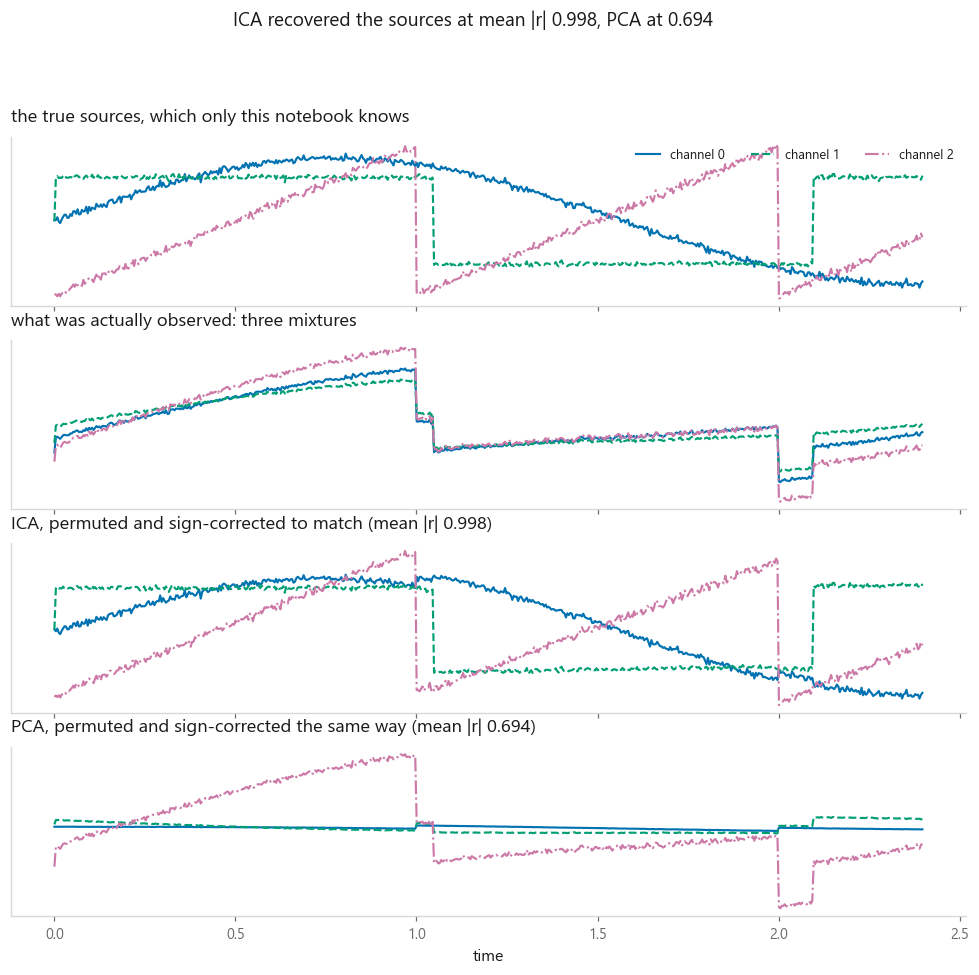

In [8]:
ica_aligned = recovered[:, ica_order] * np.sign(ica_corr)
pca_aligned = pca_recovered[:, pca_order] * np.sign(pca_corr)

fig, axes = plt.subplots(4, 1, figsize=(11.2, 9.2), sharex=True)
window = slice(0, 600)
rows = [(sources, "the true sources, which only this notebook knows", None),
        (observed, "what was actually observed: three mixtures", None),
        (ica_aligned, "ICA, permuted and sign-corrected to match", np.abs(ica_corr).mean()),
        (pca_aligned, "PCA, permuted and sign-corrected the same way", np.abs(pca_corr).mean())]

for ax, (matrix, name, score) in zip(axes, rows):
    for j in range(3):
        ax.plot(t[window], matrix[window, j], color=style.PALETTE[j * 2],
                ls=style.DASHES[j], lw=1.4, label=f"channel {j}")
    ax.set_yticks([])
    ax.grid(False)
    style.title(ax, name if score is None else f"{name} (mean |r| {score:.3f})")
axes[0].legend(loc="upper right", fontsize=8.5, ncol=3)
axes[-1].set_xlabel("time")

fig.suptitle(f"ICA recovered the sources at mean |r| {np.abs(ica_corr).mean():.3f}, "
             f"PCA at {np.abs(pca_corr).mean():.3f}",
             x=0.5, y=1.005, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-ica-recovery.png")

Read the bottom two rows against the top one. PCA had exactly the same
information and produced components that are uncorrelated and still mixtures. Its
rotation was chosen by variance, and variance is not what separates sources.

The permutation solver in `best_match` is not decoration. Without it a perfect
recovery in the wrong order scores near zero, and papers that report ICA
correlations without saying how they matched components are not reporting
anything checkable.

### NMF on Fashion-MNIST, next to PCA

Both get the same rank and the same images. The question is what the components
look like and what they cost.

In [9]:
N_IMAGES = 2500
N_COMPONENTS = 24
MAX_ITER = 250

image_pick = rng.choice(len(train_set.data), N_IMAGES, replace=False)
images = train_set.data.numpy()[image_pick].reshape(N_IMAGES, -1).astype(np.float64) / 255.0

start = time.perf_counter()
nmf = NMF(n_components=N_COMPONENTS, init="nndsvda", max_iter=MAX_ITER, tol=1e-4,
          random_state=SEED).fit(images)
nmf_seconds = time.perf_counter() - start

start = time.perf_counter()
pca = PCA(n_components=N_COMPONENTS, random_state=SEED).fit(images)
pca_seconds = time.perf_counter() - start

print(f"{N_IMAGES:,} Fashion-MNIST images, {images.shape[1]} pixels, "
      f"{N_COMPONENTS} components")
print(f"NMF : {nmf_seconds:.1f} s")
print(f"PCA : {pca_seconds:.1f} s")

negative_share_pca = float((pca.components_ < 0).mean())
negative_share_nmf = float((nmf.components_ < 0).mean())
print("\nshare of component weights that are negative")
print(f"  PCA : {negative_share_pca:.3f}")
print(f"  NMF : {negative_share_nmf:.3f}")

NEAR_ZERO = 0.01


def near_zero_share(components, fraction=NEAR_ZERO):
    """Share of weights below `fraction` of that component's largest weight."""
    peak = np.abs(components).max(axis=1, keepdims=True)
    return float((np.abs(components) < fraction * peak).mean())


print(f"\nshare of weights below {NEAR_ZERO:.0%} of their component's peak, "
      f"a rough measure of how local a component is")
print(f"  PCA : {near_zero_share(pca.components_):.3f}")
print(f"  NMF : {near_zero_share(nmf.components_):.3f}")

2,500 Fashion-MNIST images, 784 pixels, 24 components
NMF : 1.2 s
PCA : 0.1 s

share of component weights that are negative
  PCA : 0.494
  NMF : 0.000

share of weights below 1% of their component's peak, a rough measure of how local a component is
  PCA : 0.067
  NMF : 0.652


C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 250 reached. Increase it to improve convergence.
  warnings.warn(


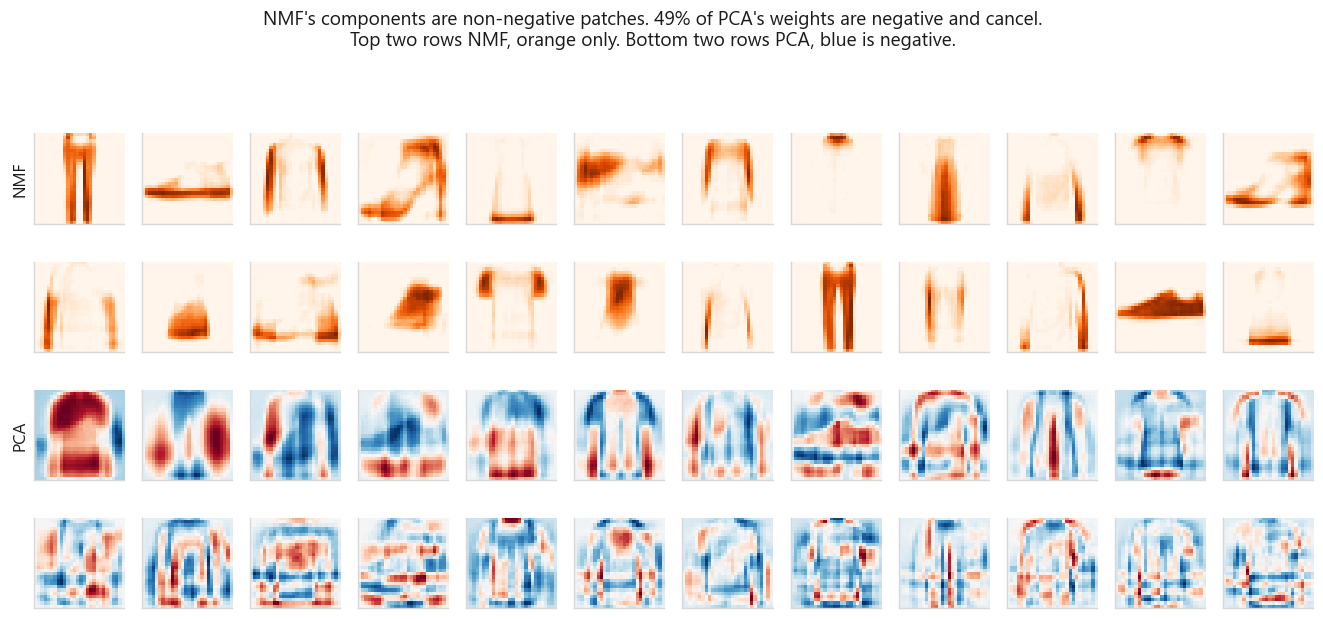

In [10]:
fig, axes = plt.subplots(4, 12, figsize=(15.0, 5.8))
for j in range(N_COMPONENTS):
    row, col = divmod(j, 12)
    axes[row, col].imshow(nmf.components_[j].reshape(28, 28), cmap="Oranges")
    axes[row + 2, col].imshow(pca.components_[j].reshape(28, 28), cmap="RdBu_r")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

axes[0, 0].set_ylabel("NMF", fontsize=11, color=style.INK)
axes[2, 0].set_ylabel("PCA", fontsize=11, color=style.INK)
fig.suptitle(f"NMF's components are non-negative patches. "
             f"{negative_share_pca:.0%} of PCA's weights are negative and cancel.\n"
             f"Top two rows NMF, orange only. Bottom two rows PCA, blue is negative.",
             x=0.5, y=1.06, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-05-nmf-vs-pca-components.png")

The PCA panels use a diverging colour map on purpose: blue is a negative weight.
A PCA component is a pattern that gets added *or subtracted*, which is why they
look like overlapping ghosts of several garments at once rather than any one
thing. The NMF panels have no negative values at all, so every component has to
earn its place by being present somewhere.

## 5. When they lose, measured

### What non-negativity cost

NMF cannot beat the truncated SVD at reconstruction. That is not an empirical
question, it is Eckart and Young's theorem: the rank-$k$ truncated SVD is the
best rank-$k$ approximation in Frobenius norm, full stop. So the interesting
number is not whether NMF loses but by how much.

The comparison has to be set up carefully. PCA subtracts the mean first, so a
rank-$k$ PCA reconstruction is really using $k$ directions **plus the mean** and
is not the matched comparison. `TruncatedSVD`, which does not centre, is.

In [11]:
from sklearn.decomposition import TruncatedSVD

ranks = [5, 10, 20, 40]
frobenius = float(np.linalg.norm(images))
records = []

for k in ranks:
    start = time.perf_counter()
    model = NMF(n_components=k, init="nndsvda", max_iter=MAX_ITER, tol=1e-4,
                random_state=SEED).fit(images)
    nmf_time = time.perf_counter() - start
    nmf_error = model.reconstruction_err_ / frobenius

    svd = TruncatedSVD(n_components=k, random_state=SEED).fit(images)
    svd_error = np.linalg.norm(images - svd.inverse_transform(svd.transform(images))) / frobenius

    p = PCA(n_components=k, random_state=SEED).fit(images)
    pca_error = np.linalg.norm(images - p.inverse_transform(p.transform(images))) / frobenius

    records.append({"rank": k, "NMF": nmf_error, "truncated SVD": svd_error,
                    "PCA (mean removed too)": pca_error,
                    "NMF seconds": nmf_time,
                    "NMF component sparsity": near_zero_share(model.components_)})

errors = pd.DataFrame(records)
errors["NMF penalty vs SVD"] = errors["NMF"] - errors["truncated SVD"]
print(errors.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 250 reached. Increase it to improve convergence.
  warnings.warn(


C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 250 reached. Increase it to improve convergence.
  warnings.warn(


 rank    NMF  truncated SVD  PCA (mean removed too)  NMF seconds  NMF component sparsity  NMF penalty vs SVD
    5 0.4118         0.4036                  0.4018       0.2320                  0.3640              0.0083
   10 0.3592         0.3442                  0.3432       0.5096                  0.4969              0.0150
   20 0.3192         0.2996                  0.2993       1.0347                  0.6145              0.0196
   40 0.2785         0.2532                  0.2530       2.4085                  0.7435              0.0253


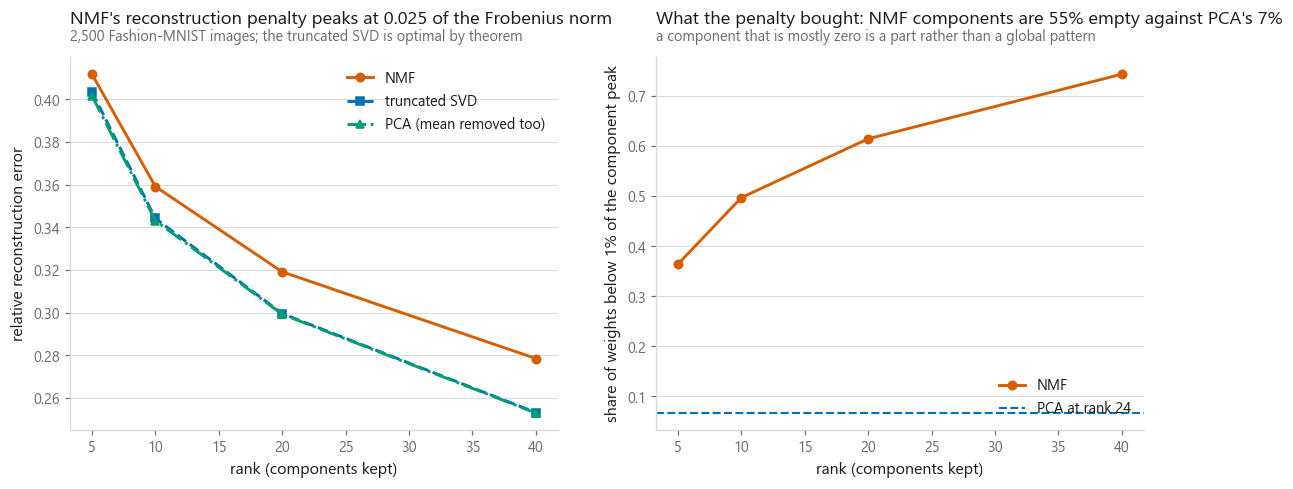

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
series = [("NMF", style.HIGHLIGHT, style.MARKERS[0], "-"),
          ("truncated SVD", style.PALETTE[0], style.MARKERS[1], "--"),
          ("PCA (mean removed too)", style.PALETTE[2], style.MARKERS[2], "-.")]
for name, colour, marker, dash in series:
    axes[0].plot(errors["rank"], errors[name], marker=marker, ls=dash, color=colour,
                 label=name)
axes[0].set_xlabel("rank (components kept)")
axes[0].set_ylabel("relative reconstruction error")
axes[0].legend(loc="upper right")
worst_penalty = errors["NMF penalty vs SVD"].max()
style.title(axes[0],
            f"NMF's reconstruction penalty peaks at {worst_penalty:.3f} of the "
            f"Frobenius norm",
            f"{N_IMAGES:,} Fashion-MNIST images; the truncated SVD is optimal by theorem")

axes[1].plot(errors["rank"], errors["NMF component sparsity"], marker=style.MARKERS[0],
             ls="-", color=style.HIGHLIGHT, label="NMF")
axes[1].axhline(near_zero_share(pca.components_), color=style.PALETTE[0], ls="--", lw=1.4,
                label=f"PCA at rank {N_COMPONENTS}")
axes[1].set_xlabel("rank (components kept)")
axes[1].set_ylabel(f"share of weights below {NEAR_ZERO:.0%} of the component peak")
axes[1].legend(loc="lower right")
style.title(axes[1],
            f"What the penalty bought: NMF components are "
            f"{errors['NMF component sparsity'].mean():.0%} empty against PCA's "
            f"{near_zero_share(pca.components_):.0%}",
            "a component that is mostly zero is a part rather than a global pattern")
style.save(fig, FIG / "fig-06-reconstruction-error.png")

Read the left panel and the right panel as a single trade. The left is what
non-negativity cost in raw reconstruction. The right is what it bought: NMF
components that are mostly zero, so each one describes a region of a garment
rather than a global pattern over all of it.

Whether that trade is worth taking depends entirely on what you wanted. If you
want the smallest reconstruction error at a given rank, take the SVD, always. If
you want components a human can look at and name, that is what you are paying
for.

### What Gaussian sources actually do to ICA

Section 2 predicted that with Gaussian sources the solution is not identified:
ICA finds the least Gaussian direction, and if every source is already Gaussian
there is nothing to find. What that prediction does not tell you is what the
output will look like, and the answer is the reason this section exists. Same
code, same mixing matrix, sources replaced by independent Gaussian noise, plus a
baseline that says what an arbitrary rotation would have scored.

In [13]:
gaussian_sources = source_rng.normal(size=(N_SAMPLES, 3))
gaussian_sources /= gaussian_sources.std(axis=0)
gaussian_observed = gaussian_sources @ mixing.T

gaussian_ica = FastICA(n_components=3, whiten="unit-variance", random_state=SEED,
                       max_iter=2000).fit_transform(gaussian_observed)
_, gaussian_corr = best_match(gaussian_sources, gaussian_ica)


def kurtosis_excess(matrix):
    """Excess kurtosis per column. Zero for a Gaussian, positive for heavy tails."""
    centred = matrix - matrix.mean(axis=0)
    scaled = centred / centred.std(axis=0)
    return (scaled ** 4).mean(axis=0) - 3.0


summary = pd.DataFrame({
    "sources": ["sine, square, sawtooth", "three independent Gaussians"],
    "mean |r| after best permutation": [np.abs(ica_corr).mean(), np.abs(gaussian_corr).mean()],
    "worst channel |r|": [np.abs(ica_corr).min(), np.abs(gaussian_corr).min()],
    "mean |excess kurtosis| of the sources": [np.abs(kurtosis_excess(sources)).mean(),
                                              np.abs(kurtosis_excess(gaussian_sources)).mean()],
})
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nexcess kurtosis is one measure of distance from a Gaussian, and it is the "
      "quantity ICA is implicitly hunting")

# The Gaussian row does not look like nothing, so it needs a baseline. If the
# theory is right, the objective is flat and the answer is an arbitrary rotation of
# the whitened data, so score arbitrary rotations the same way and compare.
ROTATIONS = 300
rotation_rng = np.random.default_rng(SEED)
random_mean, random_worst = [], []
for _ in range(ROTATIONS):
    rotation, _ = np.linalg.qr(rotation_rng.normal(size=(3, 3)))
    _, r = best_match(gaussian_sources, gaussian_sources @ rotation)
    random_mean.append(np.abs(r).mean())
    random_worst.append(np.abs(r).min())
random_mean, random_worst = np.array(random_mean), np.array(random_worst)

print(f"\n{ROTATIONS} arbitrary rotations of the same Gaussian sources, scored "
      f"identically")
print(f"  mean |r| after best permutation: {random_mean.mean():.4f} typical, "
      f"{np.percentile(random_mean, 5):.4f} to {np.percentile(random_mean, 95):.4f} "
      f"for the middle 90%")
print(f"  worst channel |r|              : {random_worst.mean():.4f} typical, "
      f"{np.percentile(random_worst, 5):.4f} to {np.percentile(random_worst, 95):.4f} "
      f"for the middle 90%")
percentile_of_ica = float((random_mean < np.abs(gaussian_corr).mean()).mean())
print(f"  ICA's Gaussian-source score sits at the {percentile_of_ica:.0%} percentile "
      f"of what an arbitrary rotation scores")

                    sources  mean |r| after best permutation  worst channel |r|  mean |excess kurtosis| of the sources
     sine, square, sawtooth                           0.9977             0.9968                                 1.5135
three independent Gaussians                           0.7683             0.6571                                 0.0668

excess kurtosis is one measure of distance from a Gaussian, and it is the quantity ICA is implicitly hunting

300 arbitrary rotations of the same Gaussian sources, scored identically
  mean |r| after best permutation: 0.8225 typical, 0.6930 to 0.9477 for the middle 90%
  worst channel |r|              : 0.7558 typical, 0.5945 to 0.9322 for the middle 90%
  ICA's Gaussian-source score sits at the 25% percentile of what an arbitrary rotation scores


C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


ICA did not break on Gaussian sources. It degraded, and that is worse.

The Gaussian row does not read as a failure. Its mean absolute correlation is
high enough to look like a method that mostly worked and could probably be
improved with a longer run or a different `fun`. Its worst channel is lower but
not obviously broken either. Handed those two numbers with no baseline, the
reasonable reading is partial recovery.

The baseline says otherwise. Arbitrary rotations of the same Gaussian sources,
scored by the same permutation solver, land in the same range, and ICA's score
sits inside that distribution rather than above it. The printed percentile is the
number to read: what ICA returned is what you get from a rotation chosen for no
reason at all. There was no partial recovery. There was an arbitrary answer that
happened to score like arbitrary answers do.

The reason the score is high in the first place is worth understanding, because
it is what makes the trap work. Three random unit vectors in three dimensions are
not close to orthogonal to a fixed basis, so an arbitrary rotation keeps a
substantial correlation with each source almost surely, and the permutation
solver then picks the most flattering assignment of the three. High absolute
correlations are the default in low dimensions, not evidence of anything. The
same scoring on the non-Gaussian row is meaningful only because it sits far above
what an arbitrary rotation reaches.

The theory says exactly this and no more. For jointly Gaussian variables,
uncorrelated implies independent, so once the data is whitened **every** rotation
gives independent components and the objective is flat. A flat objective does not
produce an obviously wrong answer; it produces an answer with nothing behind it,
and the algorithm has no way to signal the difference. The convergence warning
printed above is the only hint the run gave, and a warning is easy to dismiss as
a tolerance that needs raising.

That is the practitioner's problem in one line. The identifiability argument says
the solution is not unique, not that the output will look wrong. On real data you
do not have the true sources to correlate against, so you cannot run the check
this section just ran. What you can do is check the kurtosis of your recovered
components before you trust them: near-zero excess kurtosis across the board means
ICA had nothing to grip, whatever the components look like. If your sources really
are Gaussian, no amount of tuning will rescue this, and the correct response is to
use a different method.

### Choosing between the three

| | |
|---|---|
| **Kernel PCA** | Use when structure is curved and a linear method has plateaued. Costs $O(n^2)$ memory and $O(n^3)$ time, so subsample above a few thousand rows. `gamma` decides the answer and needs a downstream score to tune against |
| **ICA** | Use when the columns are additive mixtures of underlying sources, which is the usual situation in audio and in EEG. Requires non-Gaussian sources, and fails quietly rather than loudly when it does not have them. Returns no ordering, no scale and no sign, so match before you score |
| **NMF** | Use when the data is non-negative and you want components a person can name. Costs reconstruction error against the SVD and depends on the initialisation, so fix the seed |
| **Plain PCA** | Still the right default. It is deterministic, has no dial, has a closed form, and inverts exactly |

## Cheat sheet

| | |
|---|---|
| **Kernel PCA dials** | `kernel` (rbf is the usual start), `gamma`, `n_components`. `fit_inverse_transform=True` if you need to come back, and it is only approximate |
| **ICA dials** | `n_components`, `whiten`, `fun` (logcosh is a sane default), `max_iter`. Convergence warnings are information, not noise |
| **NMF dials** | `n_components`, `init` (`nndsvda` beats random), `solver`, `max_iter`, `alpha_W` and `l1_ratio` for sparsity |
| **Scaling** | Kernel PCA and ICA both need it. NMF needs non-negative input, so standardising would break it; scale to `[0, 1]` instead |
| **Leakage** | All three have a `transform`, so all three belong inside a pipeline and must be fitted on training rows only |
| **Next** | [t-SNE](../03-t-sne/), which gives up on being a transform at all in exchange for a better picture |

## What to remember

1. Kernel PCA runs PCA in a space it never builds, by using a kernel wherever an
   inner product was needed. Centring has to happen inside the kernel matrix.
2. Kernel PCA's `gamma` moves the result across the whole accuracy range measured
   here. It is unsupervised, so nothing inside the method will tune it for you.
3. ICA looks for the least Gaussian directions, because a mixture is more Gaussian
   than its parts. PCA gives uncorrelated components, which is a weaker property.
4. ICA fixes neither order, scale nor sign. Score it with a permutation solver or
   do not report a number.
5. Gaussian sources make ICA's objective flat, and the output does not announce
   it. The measured recovery looked like partial success and matched what an
   arbitrary rotation scores. A degraded result is more dangerous than a broken
   one, because there is nothing in it to notice. Score against a baseline, or
   check that your recovered components have any excess kurtosis at all.
6. NMF cannot beat the truncated SVD at reconstruction, by theorem. What it buys
   is components that are mostly zero and can therefore be read as parts.
7. All three change what is being maximised and keep everything else about PCA.
   That is why all three still have a `transform`, still invert approximately,
   and still belong inside a pipeline. Notice how much of that survives and how
   little of it survives the next two chapters.

Where this sits in Part 6. [06-01](../01-principal-component-analysis/) maximises
variance and found no accuracy in it; this chapter keeps the same machinery and
swaps the objective for curvature, independence or non-negativity, and each swap
bought something the variance objective could not reach.
[06-03 t-SNE](../03-t-sne/) and [06-04 UMAP](../04-umap/) are the point where the
machinery itself goes: no `transform`, no inverse, no meaningful axes, in
exchange for a picture. Read them knowing what you are giving up, because this
chapter is the last one where a reduction is still a function.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [06-03 t-SNE](../03-t-sne/) · Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#KernelPCA` `#ICA` `#NMF` `#DimensionalityReduction`
`#UnsupervisedLearning` `#Python` `#ScikitLearn` `#DataScience` `#MLTutorial`